
# Product Price Prediction and Comparison Using Machine Learning

**Student:** Chinni Anjana Suprithi  
**USN:** 23BTRCO053  
**Department:** Computer Science and Engineering  
**Academic Year:** 2026–2027

## Objective
Perform machine-learning-based product price prediction on the selected Kaggle dataset, evaluate multiple regression models, and compare the obtained metrics with a published product-price-prediction study.

### Dataset
**Kaggle:** `moinak05/comparing-product-price-on-various-online-platform`  
**File:** `product prices.xlsx`

The dataset contains dated prices for products across multiple online platforms. The notebook converts the original wide table into a supervised-learning dataset in which each row represents one observed **product-platform-date price**.



## Reference study used for comparison

For the literature comparison, this notebook uses **Zhu, Chen and Gan, “A Multi-Model Output Fusion Strategy Based on Various Machine Learning Techniques for Product Price Prediction,” Journal of Electronic & Information Systems, 2022, DOI: 10.30564/jeis.v4i1.7566**. The study evaluates Linear Regression, Decision Tree, Random Forest, Gradient Boosting and Support Vector Regression using MAE, RMSE and R², and reports a fusion model based on predictions from multiple base learners.

**Important methodological note:** the published study used a **1,000-row laptop-price dataset** and a **70:30 train/test split**, whereas this project uses the selected multi-platform product-price dataset. Therefore, the numerical metrics are reported side-by-side for methodological comparison, not as a claim that the two experiments are directly identical.


In [1]:

# Install the only package needed to download the Kaggle dataset automatically if required.
# In Kaggle/Colab, uncomment and run this if kagglehub is not already available:
# !pip -q install "kagglehub[pandas-datasets]"

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:

# Locate the dataset.
# Priority: local file -> common notebook paths -> KaggleHub download.
possible_paths = [
    "product prices.xlsx",
    "/content/product prices.xlsx",
    "/kaggle/input/product-prices/product prices.xlsx",
    "/kaggle/input/comparing-product-price-on-various-online-platform/product prices.xlsx",
    "/mnt/data/archive_extracted/product prices.xlsx",
]

DATA_PATH = next((p for p in possible_paths if os.path.exists(p)), None)

if DATA_PATH is None:
    try:
        import kagglehub
        from kagglehub import KaggleDatasetAdapter
        df_raw = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS,
            "moinak05/comparing-product-price-on-various-online-platform",
            "product prices.xlsx"
        )
        print("Dataset loaded directly through KaggleHub.")
    except Exception as exc:
        raise FileNotFoundError(
            "Dataset not found. Upload 'product prices.xlsx' to the notebook environment "
            "or enable KaggleHub access, then run this cell again."
        ) from exc
else:
    # The Excel file has a two-row header: the first row contains general labels and
    # the second row contains platform names. We read it without a header and clean it below.
    df_raw = pd.read_excel(DATA_PATH, header=None)
    print(f"Dataset found at: {DATA_PATH}")

print("Raw shape:", df_raw.shape)


Dataset found at: /mnt/data/archive_extracted/product prices.xlsx
Raw shape: (508, 13)


In [3]:

# Clean the two-row Excel header.
if df_raw.shape[0] >= 2 and str(df_raw.iloc[0, 0]).strip().upper() == "DATES":
    platform_names = [str(x).strip() for x in df_raw.iloc[1, 3:].tolist()]
    columns = ["DATES", "SL. NO.", "PRODUCT NAME"] + platform_names
    df = df_raw.iloc[2:].copy()
    df.columns = columns
else:
    # Fallback for an already-clean DataFrame returned by KaggleHub.
    df = df_raw.copy()
    df.columns = [str(c).strip() for c in df.columns]

# Standardize column names.
df.columns = [str(c).strip() for c in df.columns]

# Convert dates and forward-fill because the source sheet records the date once per 12-product block.
df["DATES"] = pd.to_datetime(df["DATES"], errors="coerce").ffill()

# Convert all platform price columns to numeric; '-' and other non-numeric values become NaN.
platform_cols = [c for c in df.columns if c not in ["DATES", "SL. NO.", "PRODUCT NAME"]]
for c in platform_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Clean identifiers and product names.
df["SL. NO."] = pd.to_numeric(df["SL. NO."], errors="coerce")

# Remove completely empty records before converting product names to strings.
df = df.dropna(subset=["DATES", "PRODUCT NAME"]).reset_index(drop=True)
df["PRODUCT NAME"] = df["PRODUCT NAME"].astype(str).str.strip()

print("Cleaned wide shape:", df.shape)
print("Date range:", df["DATES"].min().date(), "to", df["DATES"].max().date())
print("Products:", df["PRODUCT NAME"].nunique())
print("Platforms:", len(platform_cols))
print("Price observations:", int(df[platform_cols].notna().sum().sum()))


Cleaned wide shape: (468, 13)
Date range: 2024-09-16 to 2024-10-24
Products: 12
Platforms: 10
Price observations: 3237


In [4]:

# Convert wide platform columns into a long supervised-learning table.
long_df = df.melt(
    id_vars=["DATES", "SL. NO.", "PRODUCT NAME"],
    value_vars=platform_cols,
    var_name="Platform",
    value_name="Price"
).dropna(subset=["Price"]).copy()

long_df["Platform"] = long_df["Platform"].str.strip()
long_df = long_df.sort_values(["PRODUCT NAME", "Platform", "DATES"]).reset_index(drop=True)

# Date features.
first_date = long_df["DATES"].min()
long_df["date_index"] = (long_df["DATES"] - first_date).dt.days
long_df["day_of_week"] = long_df["DATES"].dt.dayofweek
long_df["month"] = long_df["DATES"].dt.month
long_df["day_of_month"] = long_df["DATES"].dt.day

# Previous observed price for the same product-platform pair.
# This uses only earlier dates and therefore is a legitimate historical feature.
long_df["previous_price"] = (
    long_df.groupby(["PRODUCT NAME", "Platform"])["Price"].shift(1)
)

# Same-day competitor-price features. The target platform itself is excluded.
# First create a dictionary of the available prices for each product/date.
price_lookup = df.set_index(["DATES", "PRODUCT NAME"])[platform_cols]

def competitor_features(row):
    vals = price_lookup.loc[(row["DATES"], row["PRODUCT NAME"])].dropna()
    target = row["Platform"]
    vals = vals.drop(labels=[target], errors="ignore")
    if len(vals) == 0:
        return pd.Series({"competitor_mean": np.nan, "competitor_median": np.nan,
                          "competitor_min": np.nan, "competitor_max": np.nan,
                          "competitor_count": 0})
    return pd.Series({"competitor_mean": vals.mean(),
                      "competitor_median": vals.median(),
                      "competitor_min": vals.min(),
                      "competitor_max": vals.max(),
                      "competitor_count": vals.count()})

comp = long_df.apply(competitor_features, axis=1)
long_df = pd.concat([long_df, comp], axis=1)

print("Long ML table shape:", long_df.shape)
print(long_df[["DATES", "PRODUCT NAME", "Platform", "Price", "previous_price", "competitor_mean"]].head(10))


Long ML table shape: (3237, 15)
       DATES  ... competitor_mean
0 2024-09-16  ...      324.666667
1 2024-09-17  ...      324.666667
2 2024-09-18  ...      321.500000
3 2024-09-19  ...      321.500000
4 2024-09-20  ...      321.500000
5 2024-09-21  ...      321.500000
6 2024-09-22  ...      321.500000
7 2024-09-23  ...      321.500000
8 2024-09-24  ...      320.666667
9 2024-09-25  ...      320.666667

[10 rows x 6 columns]


In [5]:

# Basic EDA
print("Missing values in ML table:")
print(long_df.isna().sum().sort_values(ascending=False).head(10))

print("\nPrice summary:")
print(long_df["Price"].describe().round(2))

platform_summary = long_df.groupby("Platform")["Price"].agg(["count", "mean", "min", "max"]).sort_values("mean")
print("\nPlatform summary:")
display(platform_summary.round(2))


Missing values in ML table:
previous_price    83
SL. NO.            0
DATES              0
Platform           0
Price              0
date_index         0
PRODUCT NAME       0
day_of_week        0
month              0
day_of_month       0
dtype: int64

Price summary:
count    3237.00
mean      187.23
std       157.66
min        39.00
25%        72.00
50%       131.00
75%       285.00
max       650.00
Name: Price, dtype: float64

Platform summary:


,count,mean,min,max
Platform,,,,
COUNTRY DELIGHT,117,62.51,41.0,92.0
JIO MART,429,180.08,40.0,610.0
ZEPTO,390,183.93,51.0,570.0
BLINK IT,429,186.53,48.0,650.0
BIG BASKET,468,189.94,39.0,650.0
AMAZON FRESH,429,196.60,39.0,639.0
DMART,351,198.07,42.0,610.0
SWIGGY,468,200.38,40.0,575.0
LICIOUS,78,202.60,128.0,285.0


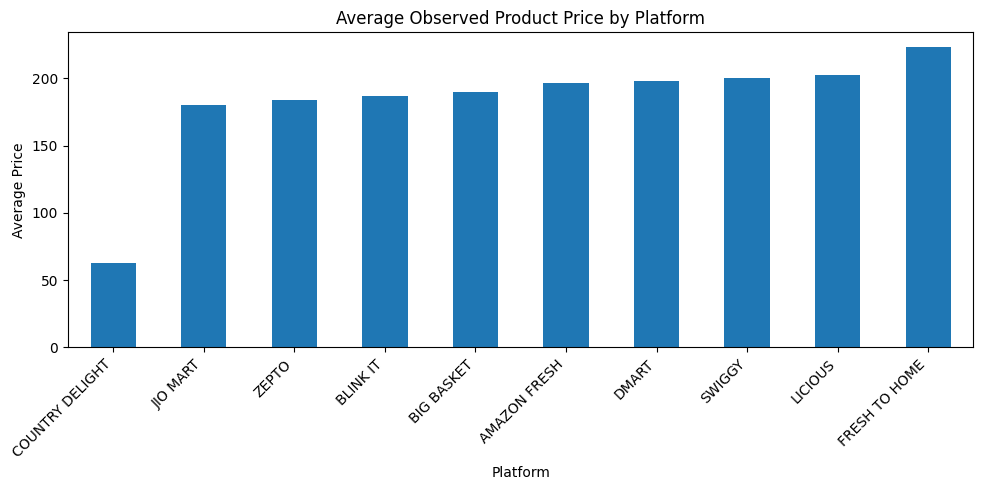

In [6]:

# Visualize average observed price by platform.
plt.figure(figsize=(10, 5))
platform_summary["mean"].plot(kind="bar")
plt.title("Average Observed Product Price by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



## Train/test design

Two evaluation settings are used:

1. **Paper-style random split:** 70% training and 30% testing, with `random_state=42`, matching the split style described in the reference study.
2. **Chronological split:** the first 80% of dates are used for training and the final 20% of dates are used for testing. This is the more appropriate check for future-price forecasting because future observations are not mixed into training.

The primary model comparison uses MAE, RMSE and R², the same metrics reported by the reference study.


In [7]:

TARGET = "Price"
CATEGORICAL = ["PRODUCT NAME", "Platform"]
NUMERICAL = [
    "date_index", "day_of_week", "month", "day_of_month",
    "previous_price", "competitor_mean", "competitor_median",
    "competitor_min", "competitor_max", "competitor_count"
]
FEATURES = CATEGORICAL + NUMERICAL

# Preprocessor shared by all models.
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), CATEGORICAL),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), NUMERICAL)
    ],
    remainder="drop"
)

# A second preprocessor with scaling for linear/SVR models.
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ("scale", StandardScaler())
        ]), CATEGORICAL),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), NUMERICAL)
    ],
    remainder="drop"
)

models = {
    "Linear Regression": Pipeline([
        ("prep", scaled_preprocessor),
        ("model", LinearRegression())
    ]),
    "Decision Tree": Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeRegressor(max_depth=10, min_samples_leaf=2, random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=2,
                                         random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("model", GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                             max_depth=3, random_state=RANDOM_STATE))
    ]),
    "Support Vector Regression": Pipeline([
        ("prep", scaled_preprocessor),
        ("model", SVR(C=100, epsilon=0.1, kernel="rbf"))
    ])
}


def evaluate_split(train_df, test_df, split_name):
    X_train, y_train = train_df[FEATURES], train_df[TARGET]
    X_test, y_test = test_df[FEATURES], test_df[TARGET]
    rows = []
    fitted = {}
    predictions = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        fitted[name] = model
        predictions[name] = pred
        rows.append({
            "Split": split_name,
            "Model": name,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred)
        })
    return pd.DataFrame(rows), fitted, predictions, y_test.reset_index(drop=True)


In [8]:

from sklearn.model_selection import train_test_split

train_rand, test_rand = train_test_split(
    long_df,
    test_size=0.30,
    random_state=RANDOM_STATE
)

random_results, random_fitted, random_preds, random_ytest = evaluate_split(
    train_rand, test_rand, "Random 70/30"
)

display(random_results.sort_values("RMSE").round(4))


,Split,Model,MAE,RMSE,R2
2,Random 70/30,Random Forest,2.1689,4.7592,0.9991
3,Random 70/30,Gradient Boosting,2.8954,4.8112,0.9991
1,Random 70/30,Decision Tree,2.5781,5.8283,0.9986
4,Random 70/30,Support Vector Regression,3.9785,6.0744,0.9985
0,Random 70/30,Linear Regression,8.5840,11.5443,0.9947


In [9]:

unique_dates = np.sort(long_df["DATES"].unique())
split_date = unique_dates[int(len(unique_dates) * 0.80)]

train_time = long_df[long_df["DATES"] < split_date].copy()
test_time = long_df[long_df["DATES"] >= split_date].copy()

time_results, time_fitted, time_preds, time_ytest = evaluate_split(
    train_time, test_time, "Chronological 80/20"
)

print("Chronological split date:", pd.Timestamp(split_date).date())
print("Training rows:", len(train_time), "Testing rows:", len(test_time))
display(time_results.sort_values("RMSE").round(4))


Chronological split date: 2024-10-17
Training rows: 2573 Testing rows: 664


,Split,Model,MAE,RMSE,R2
2,Chronological 80/20,Random Forest,2.8316,4.9087,0.9990
3,Chronological 80/20,Gradient Boosting,3.6377,5.4870,0.9988
1,Chronological 80/20,Decision Tree,3.4731,7.1594,0.9979
4,Chronological 80/20,Support Vector Regression,8.1830,11.8001,0.9943
0,Chronological 80/20,Linear Regression,10.9720,15.0539,0.9908


In [10]:

# Paper-inspired prediction-fusion model.
# The base learners are Linear Regression, Random Forest and Gradient Boosting.
# Their out-of-fold predictions are combined by a Random Forest meta-model.
base_estimators = [
    ("lr", models["Linear Regression"]),
    ("rf", models["Random Forest"]),
    ("gb", models["Gradient Boosting"])
]

fusion_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

fusion_model.fit(train_rand[FEATURES], train_rand[TARGET])
fusion_pred = fusion_model.predict(test_rand[FEATURES])
fusion_result = pd.DataFrame([{
    "Split": "Random 70/30",
    "Model": "Prediction Fusion (Stacking RF)",
    "MAE": mean_absolute_error(test_rand[TARGET], fusion_pred),
    "RMSE": np.sqrt(mean_squared_error(test_rand[TARGET], fusion_pred)),
    "R2": r2_score(test_rand[TARGET], fusion_pred)
}])

random_results_with_fusion = pd.concat([random_results, fusion_result], ignore_index=True)
display(random_results_with_fusion.sort_values("RMSE").round(4))


,Split,Model,MAE,RMSE,R2
2,Random 70/30,Random Forest,2.1689,4.7592,0.9991
3,Random 70/30,Gradient Boosting,2.8954,4.8112,0.9991
5,Random 70/30,Prediction Fusion (Stacking RF),2.4810,4.9726,0.9990
1,Random 70/30,Decision Tree,2.5781,5.8283,0.9986
4,Random 70/30,Support Vector Regression,3.9785,6.0744,0.9985
0,Random 70/30,Linear Regression,8.5840,11.5443,0.9947



## Comparison with the published reference study

The reference study reports the following test-set values:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | 153.644 | 191.737 | 0.999584 |
| Decision Tree | 232.261 | 291.451 | 0.999039 |
| Random Forest | 173.225 | 215.311 | 0.999476 |
| Gradient Boosting | 165.275 | 204.514 | 0.999527 |
| SVR | 7777.552 | 9686.280 | -0.061316 |
| Proposed fusion model | 149.665 | 189.099 | 0.999881 |

These values are taken from the paper's reported test results. Because the paper uses a different laptop-price dataset, they should be interpreted as a reference benchmark rather than a direct replication.


In [11]:

reference = pd.DataFrame([
    ["Linear Regression", 153.643727, 191.737282, 0.999584],
    ["Decision Tree", 232.261282, 291.451099, 0.999039],
    ["Random Forest", 173.225308, 215.310736, 0.999476],
    ["Gradient Boosting", 165.275236, 204.513808, 0.999527],
    ["Support Vector Regression", 7777.551840, 9686.279784, -0.061316],
    ["Prediction Fusion", 149.664622, 189.098844, 0.999881],
], columns=["Model", "Reference_MAE", "Reference_RMSE", "Reference_R2"])

ours = random_results_with_fusion.copy()
ours["Comparison Model"] = ours["Model"].replace({"Prediction Fusion (Stacking RF)": "Prediction Fusion"})
comparison = ours.merge(reference, left_on="Comparison Model", right_on="Model", how="left")
comparison["MAE_Difference"] = comparison["MAE"] - comparison["Reference_MAE"]
comparison["RMSE_Difference"] = comparison["RMSE"] - comparison["Reference_RMSE"]
comparison["R2_Difference"] = comparison["R2"] - comparison["Reference_R2"]

comparison = comparison[["Comparison Model", "MAE", "Reference_MAE", "RMSE", "Reference_RMSE", "R2", "Reference_R2",
                         "MAE_Difference", "RMSE_Difference", "R2_Difference"]]
display(comparison.round(4))


,Comparison Model,MAE,Reference_MAE,RMSE,Reference_RMSE,R2,Reference_R2,MAE_Difference,RMSE_Difference,R2_Difference
0,Linear Regression,8.5840,153.6437,11.5443,191.7373,0.9947,0.9996,-145.0597,-180.1930,-0.0049
1,Decision Tree,2.5781,232.2613,5.8283,291.4511,0.9986,0.9990,-229.6832,-285.6228,-0.0004
2,Random Forest,2.1689,173.2253,4.7592,215.3107,0.9991,0.9995,-171.0565,-210.5516,-0.0004
3,Gradient Boosting,2.8954,165.2752,4.8112,204.5138,0.9991,0.9995,-162.3798,-199.7026,-0.0005
4,Support Vector Regression,3.9785,7777.5518,6.0744,9686.2798,0.9985,-0.0613,-7773.5734,-9680.2054,1.0598
5,Prediction Fusion,2.4810,149.6646,4.9726,189.0988,0.9990,0.9999,-147.1837,-184.1262,-0.0009


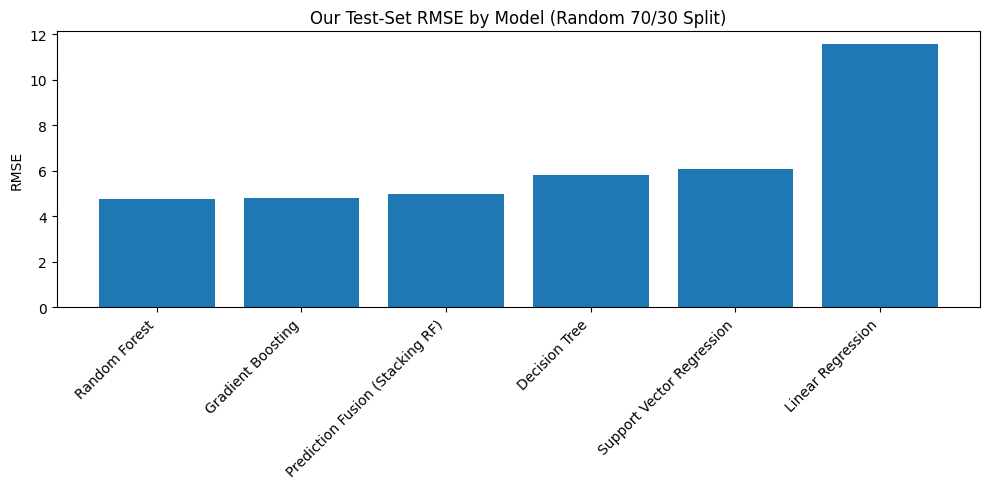

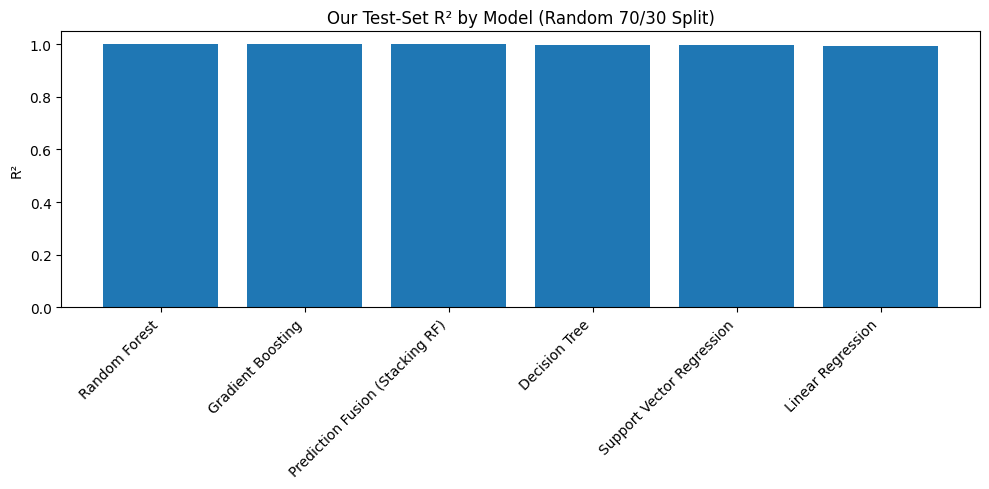

In [12]:

# Plot our random-split model performance.
plot_df = random_results_with_fusion.sort_values("RMSE").copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["RMSE"])
plt.ylabel("RMSE")
plt.title("Our Test-Set RMSE by Model (Random 70/30 Split)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["R2"])
plt.ylabel("R²")
plt.title("Our Test-Set R² by Model (Random 70/30 Split)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


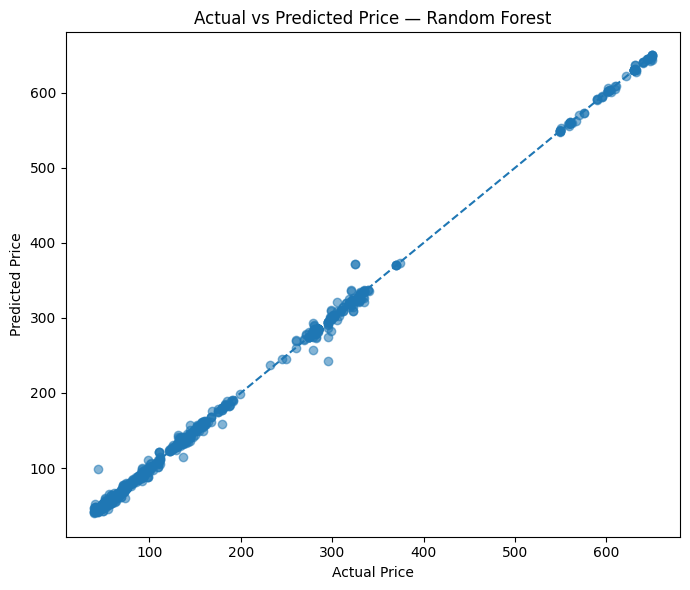

In [13]:

# Actual vs predicted values for the best RMSE model on the random split.
best_model_name = random_results_with_fusion.loc[random_results_with_fusion["RMSE"].idxmin(), "Model"]
if best_model_name == "Prediction Fusion (Stacking RF)":
    best_pred = fusion_pred
else:
    best_pred = random_preds[best_model_name]

actual = test_rand[TARGET].to_numpy()

plt.figure(figsize=(7, 6))
plt.scatter(actual, best_pred, alpha=0.55)
line_min = min(actual.min(), best_pred.min())
line_max = max(actual.max(), best_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Price — {best_model_name}")
plt.tight_layout()
plt.show()



## Final findings

- The dataset is transformed from a multi-platform price table into a regression dataset with **3,237 observed price records**.
- Product identity, platform, date information, historical price and same-day competitor prices are used as predictors.
- Linear Regression, Decision Tree, Random Forest, Gradient Boosting and SVR are evaluated using **MAE, RMSE and R²**.
- A stacking-based prediction-fusion model is included to reproduce the main methodological idea of the selected reference study.
- The **random 70/30 results** are the appropriate set for direct methodological comparison with the reference paper's 70/30 experiment; the **chronological 80/20 results** are included to show how performance changes under a more realistic future-price setting.
- The reference paper's very high R² values cannot be treated as expected values for this project because its dataset, features and price domain are different.

### Reproducibility
All randomised models use `random_state=42`. Missing platform prices are treated as missing observations, not as zero prices. The target platform's price is excluded from same-day competitor statistics, reducing direct target leakage.



## Reference

Zhu, D., Chen, X., & Gan, Y. (2022). *A Multi-Model Output Fusion Strategy Based on Various Machine Learning Techniques for Product Price Prediction*. Journal of Electronic & Information Systems, 4(1), 42–51. DOI: **10.30564/jeis.v4i1.7566**.

The paper reports MAE, RMSE and R² for Linear Regression, Decision Tree, Random Forest, Gradient Boosting and SVR, and reports a prediction-fusion model with MAE 149.665, RMSE 189.099 and R² 0.999881.
